In [ ]:
# We always start with a dataset to train on. Let's download the tiny shakespeare dataset
!wget https://raw.githubusercontent.com//karpathy//char-rnn//master//data//tinyshakespeare//input.txt

In [ ]:
with open('inputs.txt','r',encoding='utf-8') as f:
    text = f.read()

In [ ]:
print(text[:100])

In [ ]:
chars = sorted(list(set(text)))
chars_size = len(chars)
chars_size

In [ ]:
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}
encode = lambda s:[stoi[c] for c in s]
decode = lambda c:''.join(itos[i] for i in c)

encode("hello gpt"),decode([46, 43, 50, 50, 53, 1, 45, 54, 58])

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

data = torch.tensor(encode(text), dtype=torch.long)
n=int(0.9*len(data))
train = data[:n]
val = data [n:]

In [ ]:
block_size = 8
x = train[:block_size]
y = train[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f'input is : {context} ,output : {target}')

In [ ]:
torch.manual_seed(1337)
batch_size =4
block_size =8

def get_batch(split):
    data = train if split =="train" else val
    ix = torch.randint(len(data)-block_size,(batch_size,))
    x = torch.stack([data[i:i+block_size]for i in ix])
    y = torch.stack([data[i+1:i+block_size+1]for i in ix])
    return x ,y

xb,yb = get_batch('train')
print(xb.shape,yb.shape,"\n",xb,"\n",yb)
print("-"*50)
for b in range(batch_size):
    for t in range(block_size):
        context = xb[b,:t+1]
        target = yb[b,t]
        print(f"input is {context},ouput:{target}")

In [ ]:

import torch.nn as nn
import torch.nn.functional as F
import torch
torch.manual_seed(1337)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
n_embedd = 64
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table =nn.Embedding(vocab_size,n_embedd)
        self.lm_head = nn.Linear(n_embedd,vocab_size)
        self.position_embedding_table = nn.Embedding(block_size,n_embedd)

    def forward(self,idx,target=None):
        B,T = idx.shape

        logits = self.token_embedding_table(idx)
        pos_embedd = self.position_embedding_table(torch.arange(T))
        x= logits + pos_embedd
        logits = self.lm_head(x)
        B,T,C = logits.shape
        if target is None:
            loss =None
        else:    
            logits = logits.view(-1,C)
            target = target.view(B*T)
            loss = F.cross_entropy(logits,target)
        return logits,loss

    def generate(self,idx,max_new_token):
        for _ in range(max_new_token):
            idx_cond = idx[:,-self.block_size:]
            logits , loss = self(idx)
            logits = logits[:,-1,:]
            probs = F.softmax(logits,dim=-1)
            idx_next = torch.multinomial(probs,num_samples=1)
            idx = torch.cat((idx,idx_next),dim=1)
        return idx
m = BigramLanguageModel(vocab_size=chars_size)
out , loss= m(xb,yb)
print(out.shape)
idx = torch.zeros((1,1),dtype=torch.long)
decode(m.generate(idx,max_new_token=100)[0].tolist())

In [ ]:
optim =torch.optim.AdamW(m.parameters(),lr=1e-3)

In [ ]:
batch_size = 32
for steps in range(10000):
    xb,yb = get_batch('train')

    logits,loss = m(xb,yb) 
    optim.zero_grad(set_to_none=True)
    loss.backward()
    optim.step()

    print(loss.item())

In [ ]:
print(decode(m.generate(idx,max_new_token=100)[0].tolist()))

In [ ]:
B,T,C = 4,8,32
head_size = 16
key = nn.Linear(C,head_size)
query = nn.Linear(C,head_size)
value = nn.Linear(C,head_size)


tokenization , byte pair counts

In [4]:
with open('Shakespeare.txt','r',encoding='utf-8') as f:
    text = f.read()
token = text.encode("utf-8")
token = list(map(int,token))
print("-"*50)
print(len(token),len(text))
print("-"*50)

--------------------------------------------------
1115393 1115393
--------------------------------------------------


In [5]:
def get_stats(ids):
    counts ={}
    for pair in zip(ids,ids[1:]):
        counts[pair] = counts.get(pair,0)+1
    return counts

def merge(ids,pair,idx):
    new_ids = []
    i = 0
    while i<len(ids):
        if i<len(ids)-1 and ids[i]==pair[0] and ids[i+1]==pair[1]:
            new_ids.append(idx)
            i+=2
        else:
            new_ids.append(ids[i])
            i+=1
    return new_ids
stats = get_stats(token)
vocab_size = 512
num_merges = vocab_size - 256
ids = list(token)
merges = {}
for i in range(num_merges):
    stats = get_stats(ids)
    pair = max(stats,key=stats.get)
    idx = 256+i
    merges[pair] = idx
    # print(f"merging {pair} into {idx}")
    ids = merge(ids,pair,idx)
    merges[pair] = idx
    

In [25]:
len(ids),len(token),f"{len(token)/len(ids):.4f}"

(568210, 1115393, '1.9630')

In [ ]:
vocab ={idx:bytes([idx])for idx in range(256)}
for (p0,p1) ,idx in merges.items():
    vocab[idx] = vocab[p0] +vocab[p1]

def decode(ids):
    tokens = b"".jion(vocab[idx]for idx in ids)
    text = tokens.decode("utf-8",errors="replace")
    return text
def encode(text):
    token = list(text.encode("utf-8"))
    while len(text)>1:
        stats = get_stats(token)
        pair = min(stats,key=lambda p: merges.get(p,float("inf")))
        if pair not in merges:
            break
        idx = merges[pair]
        token = merge(token,pair,idx)
    return token
vocab

In [ ]:

import torch
from model.BigramLanguageModel import BigramLanguageModel

block_size = 256
batch_size = 32
epochs = 8000
eval_interval = 500
lr = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embedd = 384*2
n_head = 12
n_layer = 18
drop_out =0.4

torch.manual_seed(1337)


# with open('inputs.txt','r',encoding='utf-8') as f:
#     text = f.read()
# chars = sorted(list(set(text)))
# stoi = {ch:i for i,ch in enumerate(chars)}
# itos = {i:ch for i,ch in enumerate(chars)}

# encode = lambda s:[stoi[c] for c in s]
# decode = lambda c:''.join(itos[i] for i in c)
def get_batch(split):
    data = train if split =="train" else val
    ix = torch.randint(len(data)-block_size,(batch_size,))
    x = torch.stack([data[i:i+block_size]for i in ix])
    y = torch.stack([data[i+1:i+block_size+1]for i in ix])
    return x ,y

data = torch.tensor(encode(text), dtype=torch.long)
n=int(0.9*len(data))
train = data[:n]
val = data [n:]
vocab_size = len(chars)

with open('Shakespeare.txt','r',encoding='utf-8') as f:
    text = f.read()
token = text.encode("utf-8")
token = list(map(int,token))

def get_stats(ids):
    counts ={}
    for pair in zip(ids,ids[1:]):
        counts[pair] = counts.get(pair,0)+1
    return counts

def merge(ids,pair,idx):
    new_ids = []
    i = 0
    while i<len(ids):
        if i<len(ids)-1 and ids[i]==pair[0] and ids[i+1]==pair[1]:
            new_ids.append(idx)
            i+=2
        else:
            new_ids.append(ids[i])
            i+=1
    return new_ids
stats = get_stats(token)
vocab_size = 1024
num_merges = vocab_size - 256
ids = list(token)
merges = {}
for i in range(num_merges):
    stats = get_stats(ids)
    pair = max(stats,key=stats.get)
    idx = 256+i
    merges[pair] = idx
    # print(f"merging {pair} into {idx}")
    ids = merge(ids,pair,idx)
    merges[pair] = idx

vocab ={idx:bytes([idx])for idx in range(256)}
for (p0,p1) ,idx in merges.items():
    vocab[idx] = vocab[p0] +vocab[p1]

def decode(ids):
    tokens = b"".join(vocab[idx]for idx in ids)
    text = tokens.decode("utf-8",errors="replace")
    return text
def encode(text):
    token = list(text.encode("utf-8"))
    while len(token)>1:
        stats = get_stats(token)
        pair = min(stats,key=lambda p: merges.get(p,float("inf")))
        if pair not in merges:
            break
        idx = merges[pair]
        token = merge(token,pair,idx)
    return token



m=BigramLanguageModel(vocab_size = vocab_size,n_embedd=n_embedd,block_size=block_size,
                      num_heads=n_head,drop_out=drop_out).to(device=device)

optim = torch.optim.AdamW(m.parameters(),lr =lr)

for steps in range(epochs):
    xb,yb = get_batch('train')
    xb =xb.to(device=device)
    yb =yb.to(device=device)
    logits,loss1 = m(xb,yb) 
    optim.zero_grad(set_to_none=True)
    loss1.backward()
    optim.step()
    if steps %100 ==0:
    xb,yb = get_batch('val')
    xb =xb.to(device=device)
    yb =yb.to(device=device)
    logits,loss = m(xb,yb)
        print(f"steps:{steps},train loss:{loss1.item()},val loss:{loss.item()}")
torch.save(m.state_dict(), f'model_epoch{epochs}_layers{n_layer}_n_embedd{n_embedd}.pt')
print(decode(m.generate(torch.zeros((1,1),dtype=torch.long,device=device),max_new_token=5000)[0].tolist()))

In [7]:
import torch
def encode(text):
    token = list(text.encode("utf-8"))
    while len(token)>1:
        stats = get_stats(token)
        pair = min(stats,key=lambda p: merges.get(p,float("inf")))
        if pair not in merges:
            break
        idx = merges[pair]
        token = merge(token,pair,idx)
    return token
n=int(0.9*len(text))
train = torch.tensor(encode(text[:n]),dtype=torch.long)
val = torch.tensor(encode(text[n:]),dtype=torch.long)



In [8]:
len(train),len(val),len(train)+len(val),len(text),f"{(len(train)+len(val))/len(text):.4f}"

(511315, 56895, 568210, 1115393, '0.5094')

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"   # 强制CUDA同步，报错指向真实代码行
import torch
from model.BigramLanguageModel import BigramLanguageModel

block_size = 256
batch_size = 32
epochs = 2500
eval_interval = 500
lr = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embedd = 384
n_head = 6
n_layer = 6
drop_out =0.4
vocab_size = 512

torch.manual_seed(1337)
with open('Shakespeare.txt','r',encoding='utf-8') as f:
    text = f.read()
n=int(0.9*len(text))
# train = torch.tensor(encode(text[:n]), dtype=torch.long)
# val = torch.tensor(encode(text[n:]), dtype=torch.long)
# train = torch.tensor(train,dtype=torch.long)
# val = torch.tensor(val,dtype=torch.long)
def get_batch(split):
    data = train if split =="train" else val
    ix = torch.randint(len(data)-block_size,(batch_size,))
    x = torch.stack([data[i:i+block_size]for i in ix])
    y = torch.stack([data[i+1:i+block_size+1]for i in ix])
    return x ,y
def decode(ids):
    tokens = b"".join(vocab[idx]for idx in ids)
    text = tokens.decode("utf-8",errors="replace")
    return text
def encode(text):
    token = list(text.encode("utf-8"))
    while len(token)>1:
        stats = get_stats(token)
        pair = min(stats,key=lambda p: merges.get(p,float("inf")))
        if pair not in merges:
            break
        idx = merges[pair]
        token = merge(token,pair,idx)
    return token

m=BigramLanguageModel(vocab_size = vocab_size,n_embedd=n_embedd,block_size=block_size,
                      num_heads=n_head,drop_out=drop_out).to(device=device)

optim = torch.optim.AdamW(m.parameters(),lr =lr)

for steps in range(epochs):
    xb,yb = get_batch('train')
    xb =xb.to(device=device)
    yb =yb.to(device=device)
    logits,loss1 = m(xb,yb) 
    optim.zero_grad(set_to_none=True)
    loss1.backward()
    optim.step()

    if steps %100 ==0:
        xb,yb = get_batch('val')
        xb =xb.to(device=device)
        yb =yb.to(device=device)
        logits,loss = m(xb,yb)
        print(f"steps:{steps},train loss:{loss1.item()},val loss:{loss.item()}")
torch.save(
    {
        "model_state_dict": m.state_dict(),
        "merges": merges,
        "vocab": vocab
    }, f'bpe_model_epoch{epochs}_layers{n_layer}_n_embedd{n_embedd}.pt')
print(decode(m.generate(torch.zeros((1,1),dtype=torch.long,device=device),max_new_token=5000)[0].tolist()))

steps:0,train loss:6.415453910827637,val loss:5.944006443023682
steps:100,train loss:3.847398042678833,val loss:3.987353563308716
steps:200,train loss:3.6300017833709717,val loss:3.8631160259246826
steps:300,train loss:3.3888235092163086,val loss:3.758314609527588
steps:400,train loss:3.289795398712158,val loss:3.590341329574585
steps:500,train loss:3.039839029312134,val loss:3.4691848754882812
steps:600,train loss:2.8257696628570557,val loss:3.2727067470550537
steps:700,train loss:2.8202738761901855,val loss:3.300750970840454
steps:800,train loss:2.62231183052063,val loss:3.217151403427124
steps:900,train loss:2.6347339153289795,val loss:3.1850054264068604
steps:1000,train loss:2.6019136905670166,val loss:3.2775144577026367
steps:1100,train loss:2.5781633853912354,val loss:3.147144317626953
steps:1200,train loss:2.5397815704345703,val loss:3.03505277633667
steps:1300,train loss:2.520606279373169,val loss:3.1121737957000732
steps:1400,train loss:2.398336887359619,val loss:2.96090126037

In [35]:
# m 是你的模型实例
total_params = sum(p.numel() for p in m.parameters())
trainable_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
p=[p.numel() for p in m.parameters()]
print(f"全部参数量：{total_params:,}")
print(f"可训练参数量：{trainable_params:,}")
print(f"单位M(百万)：{trainable_params / 1e6:.2f} M")
print(p)

全部参数量：9,365,120
可训练参数量：9,365,120
单位M(百万)：9.37 M
[196608, 196608, 512, 98304, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 147456, 384, 589824, 1536, 589824, 384, 384, 384, 384, 384, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 147456, 384, 589824, 1536, 589824, 384, 384, 384, 384, 384, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 147456, 384, 589824, 1536, 589824, 384, 384, 384, 384, 384, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576, 64, 24576,

In [40]:
# 编码完tokens之后加这句
print(len(train))
print(vocab_size)

511315
512


In [ ]:
def decode(ids):
    tokens = b"".join(vocab[idx]for idx in ids)
    text = tokens.decode("utf-8",errors="replace")
    return text
# print(decode(m.generate(torch.zeros((1,1),dtype=torch.long,device=device),max_new_token=5000)[0].tolist()))

In [ ]:
b = torch.ones((5,5))
a=torch.tril(torch.ones((5,5)))
c=b.masked_fill(a==0,float('-inf'))
a,a[:5,:5],b,c,torch.nn.functional.softmax(c,dim=-1)

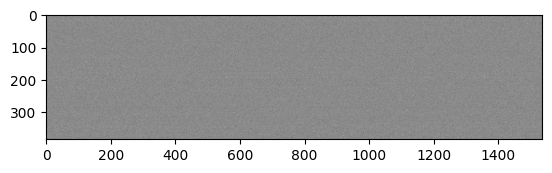

In [53]:
param = m.state_dict()
# for k,v in param.items():
#     print(k,v.shape)
import matplotlib.pyplot as plt
plt.imshow(param['blocks.0.l.l2.weight'].cpu(),cmap = 'gray')